## K-Nearest Neighbours (KNN)

**How it works:**
1. Given a new data point, compute its **distance** to every point in the training set (commonly Euclidean distance).
2. Find the **k closest** training points (the "k nearest neighbours").
3. Take a **majority vote** among those k neighbours — the most common class label wins.

KNN is a **lazy learner**: no explicit model is built during training. All computation happens at prediction time, so prediction cost grows with the size of the training set.

The choice of `k` affects the bias-variance tradeoff:
- **Small k** (e.g. k=1): low bias, high variance — sensitive to noise/outliers
- **Large k**: high bias, low variance — smoother decision boundary but may miss local patterns

**Important:** Because KNN relies on distance, features on different scales will dominate the calculation. **Feature scaling is essential.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('K-NN_Weight.csv')
df.head()

,Height,Age,Weight
0,5.0,45,76
1,5.2,26,50
2,5.6,28,55
3,6.0,34,58
4,4.9,40,71


### Understand the Data

The dataset contains physical measurements of individuals:
- **Height** (feet): ranges roughly 4.9–6.0
- **Age** (years): ranges roughly 19–45
- **Weight** (kg): the value we will use to create the class label

We will predict weight category from Height and Age.

> **Note:** This is a small demonstration dataset with only 13 rows. Evaluation results should be interpreted with caution — 3 test samples is not enough for statistically reliable accuracy estimates.

In [5]:
# Create a proper copy so the original df is not modified
df_cat = df.copy()

# Categorize by weight (kg)
# 0 = Light  (< 50 kg)
# 1 = Normal (50–64 kg)
# 2 = Heavy  (>= 65 kg)
df_cat.loc[df_cat['Weight'] < 50, 'Weight'] = 0
df_cat.loc[(df_cat['Weight'] >= 50) & (df_cat['Weight'] < 65), 'Weight'] = 1
df_cat.loc[df_cat['Weight'] >= 65, 'Weight'] = 2

label_names = {0: 'Light (<50 kg)', 1: 'Normal (50-64 kg)', 2: 'Heavy (≥65 kg)'}
df_cat

,Height,Age,Weight
0,5.0,45,2
1,5.2,26,1
2,5.6,28,1
3,6.0,34,1
4,4.9,40,2
5,5.8,36,1
6,5.2,19,0
7,5.8,29,1
8,5.5,24,0
9,5.7,31,1


## Visualize the Data

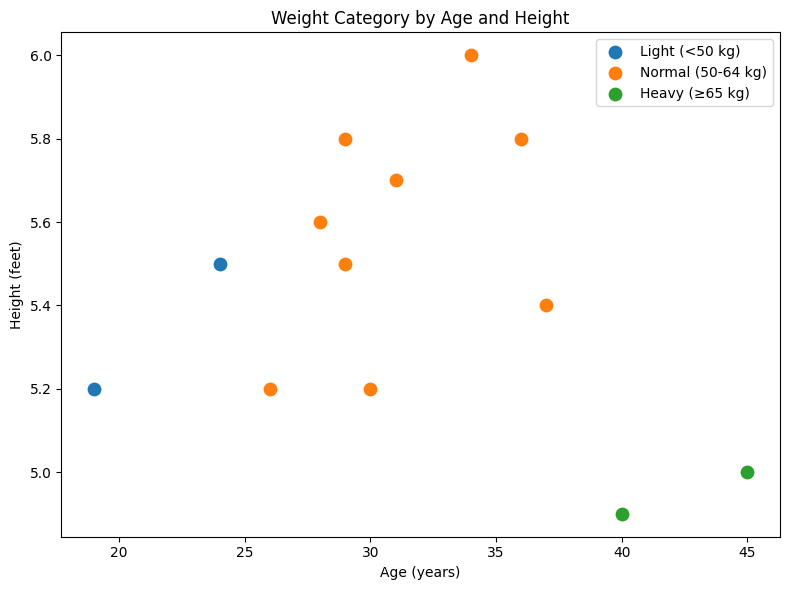

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
for label, name in label_names.items():
    subset = df_cat[df_cat['Weight'] == label]
    ax.scatter(subset['Age'], subset['Height'], label=name, color=colors[label], s=80)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Height (feet)')
ax.set_title('Weight Category by Age and Height')
ax.legend()
plt.tight_layout()
plt.show()

## Why Feature Scaling Matters for KNN

KNN measures **Euclidean distance**:

$$d = \sqrt{(H_1 - H_2)^2 + (A_1 - A_2)^2}$$

Look at the ranges in this dataset:
- Height: ~4.9 to 6.0 → range ≈ **1.1**
- Age: ~19 to 45 → range ≈ **26**

Age dominates the distance calculation by ~24×. The model will effectively ignore Height.

**Solution: `StandardScaler`** — transforms each feature to mean=0, std=1, so all features contribute equally.

> **Rule:** Always fit the scaler on **training data only**, then apply (transform) it to both training and test data. Fitting on test data would leak information.

In [7]:
X = df_cat[['Height', 'Age']]
y = df_cat['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit scaler on training data only, then apply to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Original feature ranges (training set):")
print(X_train.describe().loc[['min', 'max']])
print("\nScaled feature ranges (training set):")
print(pd.DataFrame(X_train_scaled, columns=['Height', 'Age']).describe().loc[['min', 'max']].round(2))

Original feature ranges (training set):
     Height   Age
min     4.9  19.0
max     6.0  40.0

Scaled feature ranges (training set):
     Height   Age
min   -1.72 -1.84
max    1.66  1.58


## Choosing k

There is no single best k — it depends on the data. A common approach is to try several values and pick the one with the lowest error on a held-out set. As k increases:
- Decision boundary smooths out (higher bias, lower variance)
- Prefer **odd** k for binary or 3-class problems to avoid ties

The chart below shows training and test error across odd values of k.

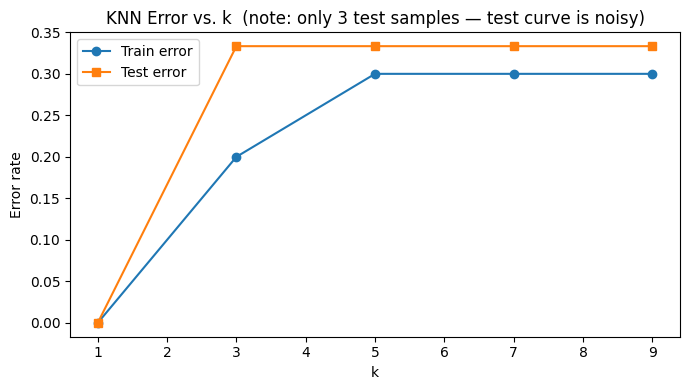

In [8]:
k_values = range(1, 10, 2)  # odd values only
train_errors = []
test_errors  = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_errors.append(1 - accuracy_score(y_train, model.predict(X_train_scaled)))
    test_errors.append( 1 - accuracy_score(y_test,  model.predict(X_test_scaled)))

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), train_errors, marker='o', label='Train error')
plt.plot(list(k_values), test_errors,  marker='s', label='Test error')
plt.xlabel('k')
plt.ylabel('Error rate')
plt.title('KNN Error vs. k  (note: only 3 test samples — test curve is noisy)')
plt.legend()
plt.tight_layout()
plt.show()

## Train Model

We use k=3 given the small dataset size.

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Evaluate the Model

Predicted: ['Normal (50-64 kg)', 'Normal (50-64 kg)', 'Normal (50-64 kg)']
Actual:    ['Normal (50-64 kg)', 'Normal (50-64 kg)', 'Heavy (≥65 kg)']

Accuracy: 0.67
(Based on only 3 test samples — not statistically reliable)


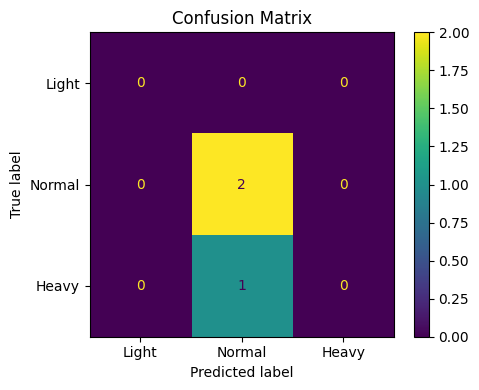

In [20]:
y_pred = knn_model.predict(X_test_scaled)

print("Predicted:", [label_names[p] for p in y_pred])
print("Actual:   ", [label_names[a] for a in y_test.values])
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("(Based on only 3 test samples — not statistically reliable)")

# Build confusion matrix over all 3 classes, even if not all appear in the test set
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Light', 'Normal', 'Heavy'])
disp.plot(ax=ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Predict a New Sample

When predicting, the new sample must be scaled using the **same scaler** fitted on the training data.

In [21]:
new_sample = pd.DataFrame({'Height': [5.5], 'Age': [30]})
new_sample_scaled = scaler.transform(new_sample)

prediction = knn_model.predict(new_sample_scaled)[0]
print(f"Prediction for Height=5.5 ft, Age=30: class {prediction} → {label_names[prediction]}")

Prediction for Height=5.5 ft, Age=30: class 1 → Normal (50-64 kg)


A person with Height 5.5 ft and Age 30 is predicted to be in the **Normal** weight category (50–64 kg).